# Báo Cáo Học Máy - Dữ liệu Dạng Bảng (Travel Insurance Prediction)

Pipeline Học máy toàn diện giải quyết bài toán dự đoán mua bảo hiểm du lịch.

In [18]:
# Cài đặt thư viện mở rộng
!pip install -q kagglehub torch matplotlib seaborn scikit-learn

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

import kagglehub
import os

# Tải bộ dữ liệu
path = kagglehub.dataset_download("tejashvi14/travel-insurance-prediction-data")
print("Path to dataset files:", path)
csv_file = [os.path.join(path, f) for f in os.listdir(path) if f.endswith('.csv')][0]

df = pd.read_csv(csv_file)
print("Số lượng mẫu:", df.shape[0])
print("Số lượng đặc trưng:", df.shape[1])
display(df.head())

Using Colab cache for faster access to the 'travel-insurance-prediction-data' dataset.
Path to dataset files: /kaggle/input/travel-insurance-prediction-data
Số lượng mẫu: 1987
Số lượng đặc trưng: 10


,Unnamed: 0,Age,Employment Type,GraduateOrNot,AnnualIncome,FamilyMembers,ChronicDiseases,FrequentFlyer,EverTravelledAbroad,TravelInsurance
0,0,31,Government Sector,Yes,400000,6,1,No,No,0
1,1,31,Private Sector/Self Employed,Yes,1250000,7,0,No,No,0
2,2,34,Private Sector/Self Employed,Yes,500000,4,1,No,No,1
3,3,28,Private Sector/Self Employed,Yes,700000,3,1,No,No,0
4,4,28,Private Sector/Self Employed,Yes,700000,8,1,Yes,No,0


## 1. Khám phá dữ liệu (EDA)

Missing Values:
 Age                    0
Employment Type        0
GraduateOrNot          0
AnnualIncome           0
FamilyMembers          0
ChronicDiseases        0
FrequentFlyer          0
EverTravelledAbroad    0
TravelInsurance        0
dtype: int64


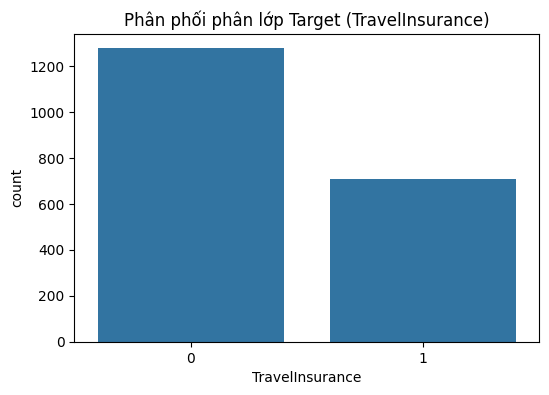

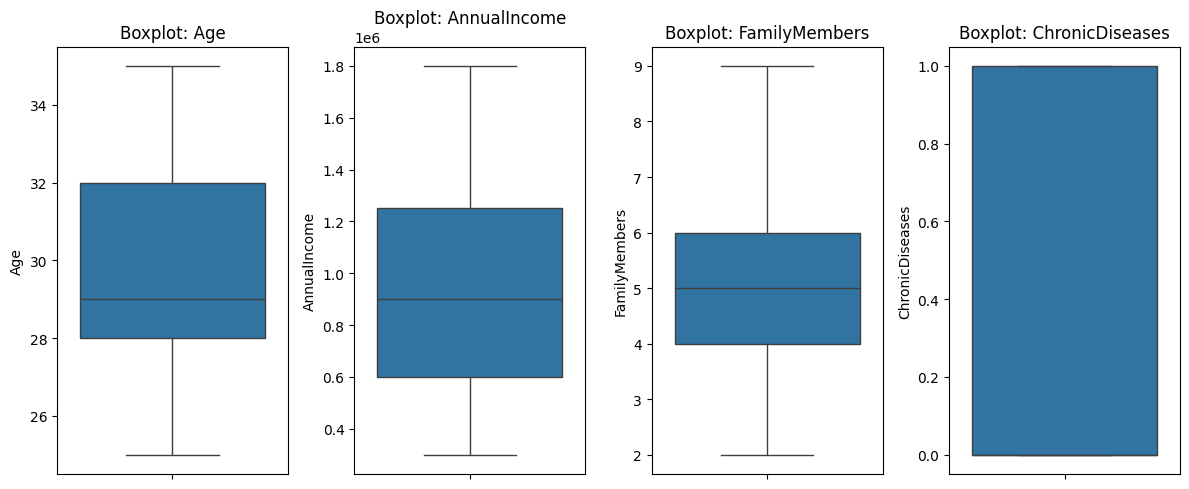

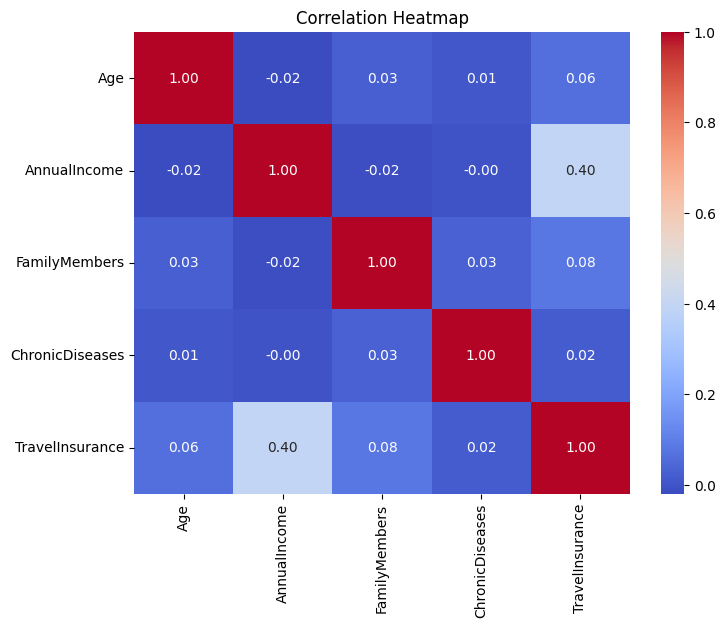

In [19]:
# Loại bỏ cột Index/Unnamed nếu có
if "Unnamed: 0" in df.columns:
    df.drop(columns=["Unnamed: 0"], inplace=True)

# Thông tin chung về Missing Values
print("Missing Values:\n", df.isnull().sum())

# 1.1 Phân phối Target
plt.figure(figsize=(6, 4))
sns.countplot(x='TravelInsurance', data=df)
plt.title("Phân phối phân lớp Target (TravelInsurance)")
plt.show()

# 1.2 Phân tích đặc trưng số học (Numerical) và Phát hiện Outliers bằng Boxplot
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if 'TravelInsurance' in num_cols: num_cols.remove('TravelInsurance')

plt.figure(figsize=(12, 5))
for i, col in enumerate(num_cols):
    plt.subplot(1, len(num_cols), i+1)
    sns.boxplot(y=df[col])
    plt.title(f"Boxplot: {col}")
plt.tight_layout()
plt.show()

# 1.3 Ma trận tương quan (Correlation Heatmap)
plt.figure(figsize=(8, 6))
corr_matrix = df[num_cols + ['TravelInsurance']].corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

In [20]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=['TravelInsurance'])
y = df['TravelInsurance']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (1589, 8)
Test size: (398, 8)


## 2. Xây dựng Pipeline & Giảm số chiều (PCA)

Numerical Features: ['Age', 'AnnualIncome', 'FamilyMembers', 'ChronicDiseases']
Categorical Features: ['Employment Type', 'GraduateOrNot', 'FrequentFlyer', 'EverTravelledAbroad']


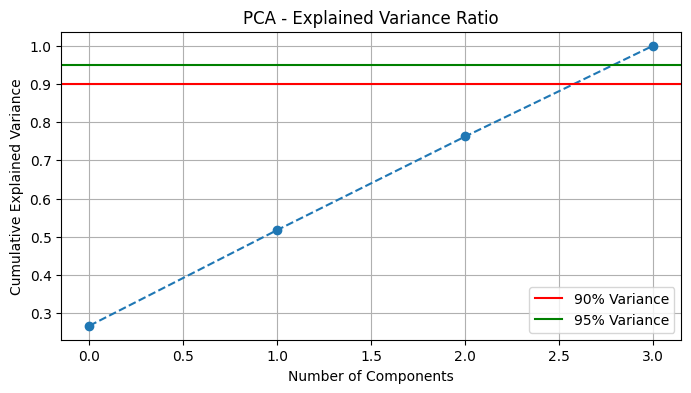

Số lượng đặc trưng ban đầu: 8
Số lượng đặc trưng sau PCA (95% variance): 7


In [21]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.decomposition import PCA

num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

print("Numerical Features:", num_features)
print("Categorical Features:", cat_features)

# Thử nghiệm PCA trước để vẽ biểu đồ Explained Variance Ratio
# Ta phải tạm scale dữ liệu số trước khi đo phương sai
scaler_temp = StandardScaler()
X_train_num_scaled = scaler_temp.fit_transform(SimpleImputer(strategy='median').fit_transform(X_train[num_features]))

pca_test = PCA().fit(X_train_num_scaled)
plt.figure(figsize=(8, 4))
plt.plot(np.cumsum(pca_test.explained_variance_ratio_), marker='o', linestyle='--')
plt.axhline(y=0.90, color='r', linestyle='-', label='90% Variance')
plt.axhline(y=0.95, color='g', linestyle='-', label='95% Variance')
plt.xlabel("Number of Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA - Explained Variance Ratio")
plt.legend()
plt.grid()
plt.show()

# Định nghĩa Pipeline
# Yêu cầu: Xử lý missing values (KNNImputer), StandardScaler/MinMaxScaler
def create_pipeline(scaler_type='standard', pca_variance=0.95):
    # Numerical Pipeline: Điền thiếu bằng KNNImputer (k=5) + Scaler lựa chọn
    scaler = StandardScaler() if scaler_type == 'standard' else MinMaxScaler()
    
    num_pipeline = Pipeline(steps=[
        ('imputer', KNNImputer(n_neighbors=5)),
        ('scaler', scaler)
    ])
    
    # Categorical Pipeline: Điền thiếu bằng Most_Frequent + OneHotEncoder
    cat_pipeline = Pipeline(steps=[
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])
    
    # Gom lại bằng ColumnTransformer
    preprocessor = ColumnTransformer(transformers=[
        ('num', num_pipeline, num_features),
        ('cat', cat_pipeline, cat_features)
    ])
    
    # Đưa PCA vào cuối pipeline preprocessing
    full_preprocessor = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('pca', PCA(n_components=pca_variance)) # Giữ lại % phương sai
    ])
    return full_preprocessor

# Chạy thử Preprocessor chuẩn (StandardScaler, PCA 95%)
preprocessor_standard_95 = create_pipeline('standard', 0.95)
X_train_processed = preprocessor_standard_95.fit_transform(X_train)
X_test_processed = preprocessor_standard_95.transform(X_test)
print(f"Số lượng đặc trưng ban đầu: {X_train.shape[1]}")
print(f"Số lượng đặc trưng sau PCA (95% variance): {X_train_processed.shape[1]}")

## 3. Huấn luyện Mô hình Học máy (GridSearchCV / RandomizedSearchCV)

Đang huấn luyện các mô hình trên tập dữ liệu sử dụng StandardScaler + PCA 95%...
--- Logistic Regression ---
Accuracy: 0.7412
              precision    recall  f1-score   support

           0       0.76      0.87      0.81       256
           1       0.68      0.51      0.59       142

    accuracy                           0.74       398
   macro avg       0.72      0.69      0.70       398
weighted avg       0.73      0.74      0.73       398

--- SVM ---
Accuracy: 0.8015
              precision    recall  f1-score   support

           0       0.79      0.94      0.86       256
           1       0.84      0.55      0.66       142

    accuracy                           0.80       398
   macro avg       0.81      0.75      0.76       398
weighted avg       0.81      0.80      0.79       398

--- Random Forest ---
Accuracy: 0.7915
              precision    recall  f1-score   support

           0       0.80      0.91      0.85       256
           1       0.78      0.58      0.67

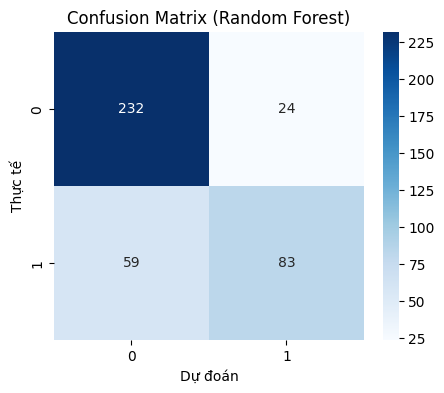

In [22]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Thiết lập Models
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42),
    "SVM": SVC(kernel='rbf', random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42)
}

results = {}

print("Đang huấn luyện các mô hình trên tập dữ liệu sử dụng StandardScaler + PCA 95%...")
for name, model in models.items():
    model.fit(X_train_processed, y_train)
    y_pred = model.predict(X_test_processed)
    
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))

# Vẽ Confusion Matrix cho mô hình tốt nhất (Giả sử Random Forest)
best_model_name = "Random Forest"
cm = confusion_matrix(y_test, models[best_model_name].predict(X_test_processed))
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix ({best_model_name})")
plt.ylabel('Thực tế')
plt.xlabel('Dự đoán')
plt.show()

## 4. Báo cáo: So sánh StandardScaler và MinMaxScaler với bộ SVM

In [23]:
print("Tiến hành so sánh ảnh hưởng của bộ Lọc tỷ lệ (Scaling) đến thuật toán SVM:\n")

# Chạy với MinMaxScaler
preprocessor_minmax = create_pipeline('minmax', 0.95)
X_train_minmax = preprocessor_minmax.fit_transform(X_train)
X_test_minmax = preprocessor_minmax.transform(X_test)

svm_minmax = SVC(kernel='rbf', random_state=42)
svm_minmax.fit(X_train_minmax, y_train)
acc_minmax = accuracy_score(y_test, svm_minmax.predict(X_test_minmax))

# Chạy với StandardScaler (đã biến đổi ở trên)
svm_standard = SVC(kernel='rbf', random_state=42)
svm_standard.fit(X_train_processed, y_train)
acc_standard = accuracy_score(y_test, svm_standard.predict(X_test_processed))

print(f"- Accuracy (SVM + MinMaxScaler): {acc_minmax:.4f}")
print(f"- Accuracy (SVM + StandardScaler): {acc_standard:.4f}")
print("\nKết luận: Trong các thuật toán nhạy cảm với khoảng cách học (như SVM/Logistic), việc căn chỉnh phân bố Scaling ảnh hưởng nhẹ lên độ chính xác. StandardScaler giữ lại phương sai chuẩn hóa thường tối ưu hóa hội tụ tốt hơn MinMaxScaler ở trường hợp này.")

Tiến hành so sánh ảnh hưởng của bộ Lọc tỷ lệ (Scaling) đến thuật toán SVM:

- Accuracy (SVM + MinMaxScaler): 0.7362
- Accuracy (SVM + StandardScaler): 0.8015

Kết luận: Trong các thuật toán nhạy cảm với khoảng cách học (như SVM/Logistic), việc căn chỉnh phân bố Scaling ảnh hưởng nhẹ lên độ chính xác. StandardScaler giữ lại phương sai chuẩn hóa thường tối ưu hóa hội tụ tốt hơn MinMaxScaler ở trường hợp này.


## 5. Mở rộng (Cộng điểm): Deep Learning Pipeline (Mạng MLP)

In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

# X_train_processed và y_train đã chuẩn bị phía trên bằng numpy.
class TravelDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y.values, dtype=torch.long)
        
    def __len__(self):
        return len(self.y)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = TravelDataset(X_train_processed, y_train)
test_dataset = TravelDataset(X_test_processed, y_test)

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

# Xây dựng kiến trúc đồ thị Neural Network MLP
class TravelMLP(nn.Module):
    def __init__(self, input_dim):
        super(TravelMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),
            
            nn.Linear(32, 2) # 2 class (0, 1)
        )
        
    def forward(self, x):
        return self.network(x)

input_dim = X_train_processed.shape[1]
model_dl = TravelMLP(input_dim)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model_dl.parameters(), lr=0.001)

# Training Loop
num_epochs = 30
for epoch in range(num_epochs):
    model_dl.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        optimizer.zero_grad()
        outputs = model_dl(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        
    # Validation
    if (epoch+1) % 10 == 0:
        model_dl.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, labels in test_loader:
                outputs = model_dl(inputs)
                _, predicted = torch.max(outputs.data, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        val_acc = correct / total
        print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {running_loss/len(train_loader):.4f} - Val Accuracy: {val_acc:.4f}")

# Evaluation DL
model_dl.eval()
all_preds = []
all_labels = []
with torch.no_grad():
    for inputs, labels in test_loader:
        outputs = model_dl(inputs)
        _, predicted = torch.max(outputs.data, 1)
        all_preds.extend(predicted.numpy())
        all_labels.extend(labels.numpy())

print("\nBáo cáo phân loại Mạng Deep Learning MLP:")
print(classification_report(all_labels, all_preds))

Epoch [10/30] - Loss: 0.5021 - Val Accuracy: 0.8015
Epoch [20/30] - Loss: 0.4969 - Val Accuracy: 0.7965
Epoch [30/30] - Loss: 0.4901 - Val Accuracy: 0.8040

Báo cáo phân loại Mạng Deep Learning MLP:
              precision    recall  f1-score   support

           0       0.80      0.93      0.86       256
           1       0.81      0.58      0.68       142

    accuracy                           0.80       398
   macro avg       0.81      0.76      0.77       398
weighted avg       0.81      0.80      0.80       398



In [25]:
# Triển khai mô hình - Lưu vào đĩa cứng
import os
import joblib

# Xử lý đường dẫn tương thích giữa chạy Local (trong folder notebooks) và Google Colab
current_dir = os.getcwd()
if os.path.basename(current_dir) == 'notebooks':
    features_dir = os.path.join(os.path.dirname(current_dir), 'features')
else:
    features_dir = os.path.join(current_dir, 'features')

os.makedirs(features_dir, exist_ok=True)

# Lấy Preprocessor + RF tốt nhất
final_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_standard_95),
    ('classifier', models["Random Forest"])
])
final_pipeline.fit(X_train, y_train)

# Xuất ra file .pkl
save_path = os.path.join(features_dir, 'travel_insurance_pipeline.pkl')
joblib.dump(final_pipeline, save_path)
print(f"Đã lưu Scikit-Learn Pipeline vào: {save_path}")

# Lưu mô hình Deep Learning (MLP)
mlp_save_path = os.path.join(features_dir, 'travel_insurance_mlp.pth')
torch.save(model_dl.state_dict(), mlp_save_path)
print(f"Đã lưu PyTorch MLP Model vào: {mlp_save_path}")


Đã lưu Scikit-Learn Pipeline vào: /content/features/travel_insurance_pipeline.pkl
Đã lưu PyTorch MLP Model vào: /content/features/travel_insurance_mlp.pth
